In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

param_dict = {'spinewidth':2,
              'linewidth':4,
              'ticklength':6,
              'tickwidth':3,
              'ticklabelsize':20,
              'axislabelsize':20,
              'titlesize':25}
import matplotlib
def neaten_plot(neatenme, param_dict=param_dict):
    if isinstance(neatenme,matplotlib.figure.Figure):
        for ax in neatenme.axes:
            neaten_plot(ax)
        plt.tight_layout()
    elif isinstance(neatenme,matplotlib.axes.Axes):
        neatenme.tick_params(labelsize=param_dict['ticklabelsize'],length=param_dict['ticklength'],width=param_dict['tickwidth'])
        neatenme.xaxis.get_label().set_fontsize(param_dict['axislabelsize'])
        neatenme.yaxis.get_label().set_fontsize(param_dict['axislabelsize'])
        neatenme.title.set_fontsize(param_dict['titlesize'])
        for axis in ['top','bottom','left','right']:
            neatenme.spines[axis].set_linewidth(param_dict['spinewidth'])
        for line in neatenme.lines:
            line.set_linewidth(param_dict['linewidth'])

def plot_jungfrau(x,y,z,ax=None,shading='nearest',*args,**kwargs):
    if not ax:
        ax=plt.gca()
    for i in range(8):
        pcm = ax.pcolormesh(x[i],y[i],z[i],shading=shading,*args,**kwargs)
    return pcm

def createBinsFromCenters(centers):
    bins = []
    nc = centers.size
    for idx,c in enumerate(centers):
        if idx == 0:
            dc = np.abs( c - centers[idx+1])/2.
            bins.append(c-dc)
            bins.append(c+dc)
        elif idx == nc-1:
            dc = np.abs( c - centers[idx-1])/2.
            bins.append(c+dc)
        else:
            dc = np.abs( c - centers[idx+1])/2.
            bins.append(c+dc)
    return np.sort(np.array(bins))
            
def get_tree(f):
    """List the full tree of the h5 file"""
    def printname(name):  # needed because .visit needs callable
        print(name, type(f[name]))
    f.visit(printname)
    
def is_leaf(dataset):
    return isinstance(dataset,h5py.Dataset)

def get_leaves(f,saveto,verbose=False):
    def return_leaf(name):
        if is_leaf(f[name]):
            if verbose:
                print(name,f[name][()].shape)
            saveto[name] = f[name][()]
    f.visit(return_leaf)

def runNumToString(num):
    numstr = str(num)
    while len(numstr)<4:
        numstr = '0'+numstr
    return numstr

In [11]:
keys_to_combine = [#'tt/FLTPOS',
                   #'tt/AMPL',
                   #'tt/FLTPOSFWHM',
                   #'tt/ttCorr',
                   #'tt/FLTPOS_PS',
                   #'tt/AMPL',
                   #'tt/AMPLNXT',
                   #'tt/FLTPOS',
                   #'tt/FLTPOS_PS',
                   #'tt/REFAMPL',
                   #'epicsAll/photonBeam_Wavelength',
                   #'scan/lxt_ttc',
                   #'ipm_hfx_dg2/sum',
                   #'ipm_dg2/sum',
                   #'ipm_dg3/sum',
                   #'gas_detector/f_22_ENRC',
                   #'epicsAll/gasCell_pressure',
                   #'jungfrau4M/azav_azav',
                   'evr/code_183',
                   #'evr/code_162',
                   #'evr/code_141',
                   #'evr/code_137',
                   #'lightStatus/laser',
                   #'lightStatus/xray',
                   'ebeam/photon_energy',
                   # 'scan/var0',
                   #  'scan/LAS:FS5:MMS:PH',
                  'damage/FEE_SPEC0']
keys_to_sum = [#'Sums/jungfrau4M_calib'
              ]#,
#               'Sums/jungfrau4M_calib_xrayOn',
#               'Sums/jungfrau4M_calib_dropped',
#               'Sums/jungfrau4M_calib_thresADU14']
keys_to_check = [#'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                #'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                # 'UserDataCfg/jungfrau4M/azav__azav_qbins',
                # 'UserDataCfg/jungfrau4M/x',
                # 'UserDataCfg/jungfrau4M/y',
                # 'UserDataCfg/jungfrau4M/z',
                #'UserDataCfg/jungfrau4M/azav__azav_matrix_q',
#                 #'UserDataCfg/jungfrau4M/azav__azav_matrix_phi',
#                 'UserDataCfg/jungfrau4M/cmask',
# #                'UserDataCfg/jungfrau4M/Full_thres__Full_thres_thresADU',
# #                'UserDataCfg/jungfrau4M/Full_thres__Full_thres_bound',
#                 'UserDataCfg/jungfrau4M/common_mode_pars'
                ]

def combineRuns(runNumbers,folder,verbose=True):
    data_array = []
    for i,runNumber in enumerate(runNumbers):
        data = {}
        filename = f'{folder}cxil1015022_Run{runNumToString(runNumber)}.h5'
        print(filename)
        with h5py.File(filename,'r') as f:
            get_leaves(f,data,verbose=verbose)
            data_array.append(data)
    hf1 = h5py.File(filename, 'r')
    print(list(hf1.keys()))
#    for key in hf1['epicsAll']:
#        print(key)
    data_combined = {}
    for key in keys_to_combine:
        arr = np.squeeze(data_array[0][key])
        for data in data_array[1:]:
            arr = np.concatenate((arr,np.squeeze(data[key])),axis=0)
        data_combined[key] = arr
    run_indicator = np.array([])
    for i,runNumber in enumerate(runNumbers):
        run_indicator = np.concatenate((run_indicator,runNumber*np.ones_like(data_array[i]['tt/FLTPOS'])))
    data_combined['run_indicator'] = run_indicator  
    for key in keys_to_sum:
        arr = np.zeros_like(data_array[0][key])
        for data in data_array:
            arr += data[key]
        data_combined[key] = arr
    for key in keys_to_check:
        arr = data_array[0][key]
        for i,data in enumerate(data_array):
            if not np.array_equal(data[key],arr):
                print(f'Problem with key {key} in run {runNumbers[i]}')
        data_combined[key] = arr
    return data_combined

In [13]:
runNumbers = [49]
#folder = '/cds/data/drpsrcf/cxi/cxilv1118/scratch/hdf5/smalldata/' #Old FFB
#folder = '/cds/data/psdm/cxi/cxilv1118/hdf5/smalldata/' #Old Ana
#folder = '/sdf/data/lcls/ds/cxi/cxilx6520/results/processed_runs/' #Custom
#folder = '/sdf/data/lcls/drpsrcf/ffb/cxi/cxix1000021/hdf5/smalldata'#New FFB
#folder = '/sdf/data/lcls/ds/cxi/cxilx6520/scratch/processed_runs/' #New Ana
folder = '/sdf/data/lcls/ds/cxi/cxil1015022/hdf5/smalldata/' #New Ana

data = combineRuns(runNumbers,folder=folder,verbose=False)

#photonBeam_Wavelength = data['epicsAll/photonBeam_Wavelength']
#ttpos = data['tt/FLTPOS']
#ttampl = data['tt/AMPL']
#ttfwhm = data['tt/FLTPOSFWHM']
#ttcorr = data['tt/ttCorr']
#ttps = data['tt/FLTPOS_PS']
#scan = data['scan/LAS:FS5:MMS:PH']
#scan = data['scan/lxt_ttc']
#scan = data['scan/lxt']
phot_energy = data['ebeam/photon_energy']
#q = data['UserDataCfg/jungfrau4M/azav__azav_q']
#qbin = data['UserDataCfg/jungfrau4M/azav__azav_qbin']
#qbins = data['UserDataCfg/jungfrau4M/azav__azav_qbins']
# x = data['UserDataCfg/jungfrau4M/x']
# y = data['UserDataCfg/jungfrau4M/y']
# z = data['UserDataCfg/jungfrau4M/z']
specData = data['damage/FEE_SPEC0']
#matrix_q = data['UserDataCfg/jungfrau4M/azav__azav_matrix_q'].reshape(8,512,1024)
#matrix_phi = data['UserDataCfg/jungfrau4M/azav__azav_matrix_phi'].reshape(8,512,1024)
#dg2 = data['ipm_hfx_dg2/sum']
# dg2 = data['ipm_dg2/sum']
# #dg3 = data['ipm_dg3/sum']
# #pressure = data['epicsAll/gasCell_pressure']
# xray_energy = data['gas_detector/f_22_ENRC']
#azav = np.squeeze(data['jungfrau4M/azav_azav'])
#azav = np.nanmean(azav,axis=1)
#pressure = data['epicsAll/gasCell_pressure']
laserOn = data['evr/code_183'].astype(bool)
# #xrayOn = data['evr/code_162'].astype(bool)
# xrayOn_backup = data['evr/code_137'].astype(bool)
# xray_even = data['evr/code_141'].astype(bool)
# laserOn2 = data['lightStatus/laser'].astype(bool)
# xrayOn2 = data['lightStatus/xray'].astype(bool)
# #jungfrau_sum = data['Sums/jungfrau4M_calib']
# #on_sum = data['Sums/jungfrau4M_calib_xrayOn']
# #dropped_sum = data['Sums/jungfrau4M_calib_dropped']
# #jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU14']
# #jungfrau_sum[jungfrau_sum>100*np.median(jungfrau_sum)]=0
# run_indicator = data['run_indicator']
# cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool)
# #cmask1 = np.load('/reg/d/psdm/cxi/cxilx6520/results/Masks/Mask_Jungfrau_178_214_Improved.npy')
# #cmask2 = np.load('/reg/d/psdm/cxi/cxilx6520/results/Masks/Mask_Jungfrau_178_214_Platinum.npy')
# #cmask1 = np.load('/reg/d/psdm/cxi/cxilx6520/scratch/nag1647/Mask_Jungfrau_182_183_186_SF6_Tuned_lax.npy')
# #cmask2 = np.load('/reg/d/psdm/cxi/cxilx6520/scratch/nag1647/Mask_Jungfrau_182_183_186_SF6_Tuned_strict.npy')
# #cmask1 = np.load('/sdf/home/n/nag1647/Fast_Analysis/Masks/line_mask.npy') #For testing the notebook
# cmask1 = np.ones((8,512,1024))
# #cmask2 = np.ones((8,512,1024)) #For testing the notebook
# cmask2 = np.load('/sdf/data/lcls/ds/cxi/cxil1006021/scratch/nag1647/Masks/Mask_Jungfrau_19_29.npy')
# cmask3 = np.load('/sdf/data/lcls/ds/cxi/cxil1006021/scratch/nag1647/Masks/Mask_Jungfrau_29.npy')
# cmask_tot = cmask #Can multiply to combine different masks here
# #threshold = data['UserDataCfg/jungfrau4M/Full_thres__Full_thres_thresADU']
# #cmpars = data['UserDataCfg/jungfrau4M/common_mode_pars']


/sdf/data/lcls/ds/cxi/cxil1015022/hdf5/smalldata/cxil1015022_Run0049.h5
['Acqiris', 'Sums', 'UserDataCfg', 'alvium_u1', 'damage', 'ebeam', 'epics', 'event_time', 'evr', 'feeBld', 'fiducials', 'gas_detector', 'ipm_dg2', 'ipm_hx2', 'jungfrau4M', 'lightStatus', 'proc_event_time', 'scan', 'tt', 'ttRefit_IG', 'ttRefit_LFH']


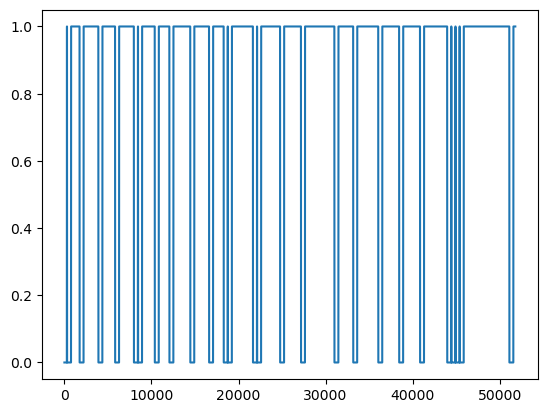

In [16]:
plt.plot(specData)

In [17]:
f = h5py.File('/sdf/data/lcls/ds/cxi/cxil1015022/hdf5/smalldata/cxil1015022_Run0049.h5','r')
get_tree(f)

Acqiris <class 'h5py._hl.group.Group'>
Acqiris/FastTiming_area <class 'h5py._hl.dataset.Dataset'>
Acqiris/Laser_area <class 'h5py._hl.dataset.Dataset'>
Sums <class 'h5py._hl.group.Group'>
Sums/Acqiris_calib <class 'h5py._hl.dataset.Dataset'>
Sums/Acqiris_calib_dropped <class 'h5py._hl.dataset.Dataset'>
Sums/Acqiris_calib_dropped_thresADU1 <class 'h5py._hl.dataset.Dataset'>
Sums/Acqiris_calib_square <class 'h5py._hl.dataset.Dataset'>
Sums/Acqiris_calib_thresADU1 <class 'h5py._hl.dataset.Dataset'>
Sums/Acqiris_calib_thresADU14 <class 'h5py._hl.dataset.Dataset'>
Sums/Acqiris_calib_xrayOn <class 'h5py._hl.dataset.Dataset'>
Sums/Acqiris_calib_xrayOn_thresADU1 <class 'h5py._hl.dataset.Dataset'>
Sums/alvium_u1_calib <class 'h5py._hl.dataset.Dataset'>
Sums/alvium_u1_calib_dropped <class 'h5py._hl.dataset.Dataset'>
Sums/alvium_u1_calib_dropped_thresADU1 <class 'h5py._hl.dataset.Dataset'>
Sums/alvium_u1_calib_square <class 'h5py._hl.dataset.Dataset'>
Sums/alvium_u1_calib_thresADU1 <class 'h5py._

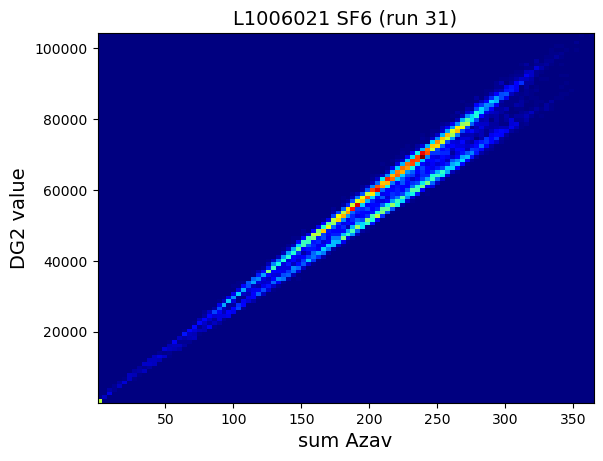

In [5]:
good_indices = np.where((np.sum(azav, axis = 1) > 0) & (dg2 > 0))[0]
plt.figure()
plt.hist2d(np.sum(azav[good_indices], axis = 1), dg2[good_indices], bins = 100, cmap = 'jet')
plt.xlabel('sum Azav', fontsize = 14)
plt.ylabel('DG2 value', fontsize = 14)
plt.title('L1006021 SF6 (run 31)', fontsize = 14)
plt.show()
#plt.savefig('L1006021.png', dpi = 150., bbox_inches = 'tight')

/lscratch/davidjr/tmp/ipykernel_2992222/3368595988.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x[i],y[i],z[i],shading=shading,*args,**kwargs)


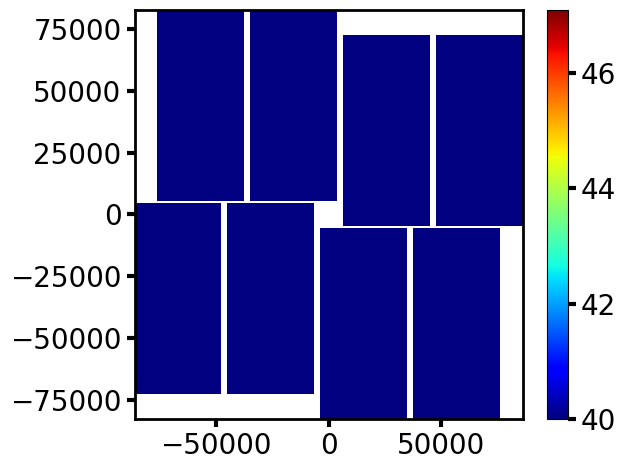

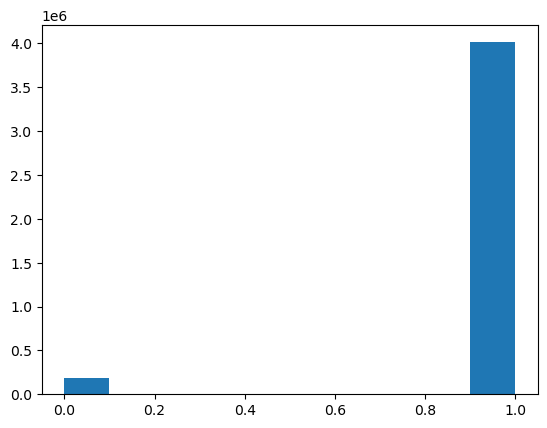

In [10]:
#mask0 = cmask_tot
#mask0 = cmask2
mask0 = np.ones((8,512,1024))
#mask1 = np.load('/sdf/data/lcls/ds/cxi/cxil1006021/scratch/nag1647/Masks/Mask_Jungfrau_418_429.npy')
#mask2 = np.load('gain_correction_array.npy')
#mask1 = np.nan_to_num(mask2[0,:,:,:])
mask1 = np.load('/sdf/data/lcls/ds/cxi/cxil1006021/scratch/nag1647/Masks/run294_mask_xray.npy')
#mask1 = np.nan_to_num(mask1)
#print(np.unique(mask1))
#mask1[7,:,:] = 0
#instrument_response = np.load('/reg/d/psdm/cxi/cxilx9320/results/Instrument_Response/IRF_Ne_run6.npy')
instrument_response = np.ones((8,512,1024))
# jungfrau_sum = jungfrau_sum.astype('float64')
# jungfrau_sum *= np.nan_to_num(mask0)
# jungfrau_sum *= np.nan_to_num(instrument_response)

# onshots = np.where(laserOn == True)[0]
# offshots = np.where(laserOn == False)[0]
# uvonshots = onshots.size
# uvoffshots = offshots.size

# jungfrau_sum /= (uvonshots + uvoffshots)

# print(np.unique(jungfrau_sum))

#pcm = plot_jungfrau(-y,x,np.log10(abs(jungfrau_sum)),cmap = 'jet')#, vmin = 0)
#pcm = plot_jungfrau(-y,x,on_sum,cmap='jet')#, vmin = 0, vmax = 50000)
#pcm = plot_jungfrau(-y,x,dropped_sum,cmap='jet')
# pcm = plot_jungfrau(-y,x,jungfrau_sum,vmax=1e-2)
pcm = plot_jungfrau(y,-x,mask1, cmap = 'jet', vmin = 40., vmax = 47.1)
plt.colorbar(pcm)
neaten_plot(plt.gcf())

plt.figure()
plt.hist(mask1.flatten())
plt.show()


In [20]:
#total_uvoffs = (uvons1*uvonshots1 + uvoffs1*uvoffshots1)/(uvonshots1 + uvoffshots1)
print(12400./15150.)
print( 12400./0.8181078)

0.8184818481848185
15156.926752195737


## Initial Plots

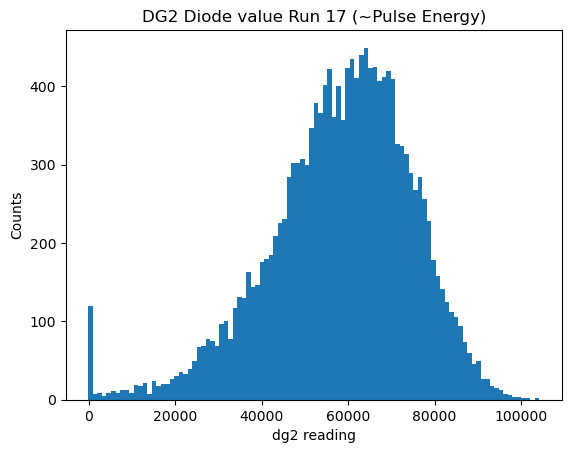

In [11]:
plt.figure()
plt.hist(dg2, bins = 100)
plt.xlabel('dg2 reading')
plt.ylabel('Counts')
plt.title('DG2 Diode value Run 17 (~Pulse Energy)')
plt.show()
#plt.savefig('dg2_run%d.png' % runNumbers[0])

# Calculating detector efficiency

## Enter Energy Here in keV

In [12]:
Average_Energy = np.nanmedian(phot_energy/1000.)
#Average_Energy = 9.9

## Silicon Mass Attenuation

/lscratch/davidjr/tmp/ipykernel_2992222/1334268565.py:9: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  Ref_Values = np.arange(np.float(E_values[low_bin]), np.float(E_values[high_bin]) + 0.5, .01, float)


Si cross section is 33.832 cm^2/g


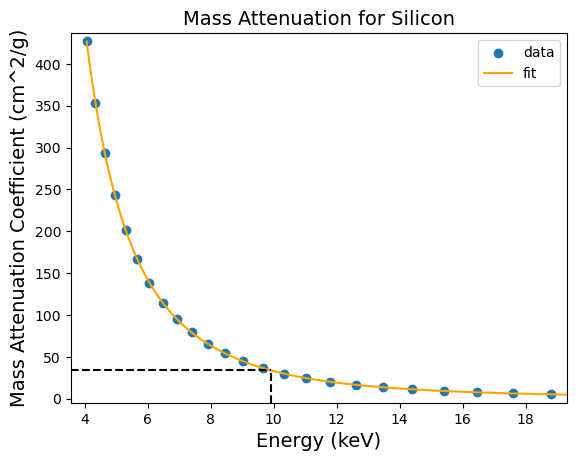

In [13]:
from scipy.interpolate import InterpolatedUnivariateSpline

E_values = np.array([4.055024, 4.334821, 4.633924, 4.953664, 5.295467, 5.660855, 6.051453, 6.469004, 6.915365,  7.392525,  7.902609, 8.447890, 9.030794, 9.653919, 10.32004, 11.03212, 11.79334, 12.60708, 13.47697, 14.40688, 15.40095, 16.46362, 17.59961, 18.81398]) #NIST
Mu_values = np.array([426.77, 353.66, 293.11, 242.97, 201.42, 167.00, 138.48, 114.86, 95.280, 79.055, 65.607, 54.160, 44.613, 36.539, 29.938, 24.541, 20.129, 16.519, 13.566, 11.150, 9.1726, 7.5540, 6.2286, 5.1429]) ##Nist
#Extrapolating to Experimental Photon Energy
low_bin = 0
high_bin = 23
Mu_Spline = InterpolatedUnivariateSpline(E_values, Mu_values)
Ref_Values = np.arange(np.float(E_values[low_bin]), np.float(E_values[high_bin]) + 0.5, .01, float)
fit_pattern = Mu_Spline(Ref_Values)

#Average_Energy = np.nanmedian(fee_data)
Energy_Bin = np.digitize(Average_Energy, Ref_Values)
mass_attenuation_coefficient_Si = fit_pattern[Energy_Bin]
print('Si cross section is %.3f cm^2/g' % mass_attenuation_coefficient_Si)

plt.figure()
plt.scatter(E_values, Mu_values, label = 'data')
plt.plot(Ref_Values, fit_pattern, color = 'orange', label = 'fit')
plt.vlines(Average_Energy, np.min(Mu_values) - 10, mass_attenuation_coefficient_Si, linestyle = 'dashed', color = 'black')
plt.hlines(mass_attenuation_coefficient_Si, np.min(E_values) - 0.5, Average_Energy, linestyle = 'dashed', color = 'black')
plt.xlabel('Energy (keV)', fontsize = 14)
plt.ylabel('Mass Attenuation Coefficient (cm^2/g)', fontsize = 14)
plt.title('Mass Attenuation for Silicon', fontsize = 14)
plt.legend()
plt.xlim(np.min(E_values) - 0.5, np.max(E_values) + 0.5)
plt.ylim(np.min(Mu_values) - 10, np.max(Mu_values) + 10)
plt.show()
#plt.savefig('Mass_Attenuation_15_155.png')

## Aluminum mass attenuation

/lscratch/davidjr/tmp/ipykernel_2992222/345031938.py:8: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  Ref_Values = np.arange(np.float(E_values[low_bin]), np.float(E_values[high_bin]) + 0.5, .01, float)


Al cross section is 70.560 cm^2/g


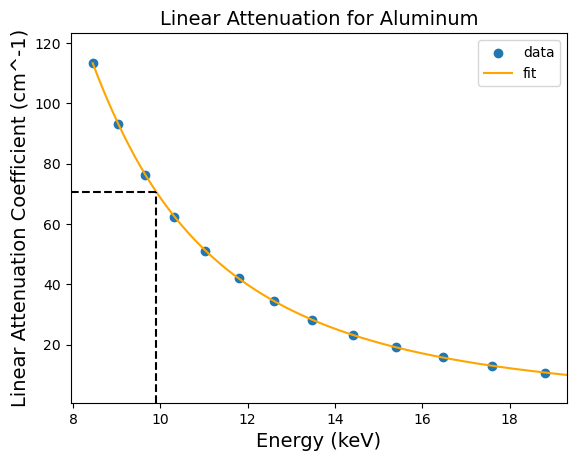

In [14]:
from scipy.interpolate import InterpolatedUnivariateSpline
E_values = np.array([8.447890, 9.030794, 9.653919, 10.32004, 11.03212, 11.79334, 12.60708, 13.47697, 14.40688, 15.40095, 16.46362, 17.59961, 18.81398]) #NIST
Mu_values = np.array([113.27, 93.247, 76.294, 62.454, 51.152, 41.923, 34.382, 28.226, 23.192, 19.078, 15.714, 12.963, 10.712]) ##Nist
#Extrapolating to Experimental Photon Energy
low_bin = 0
high_bin = 12
Mu_Spline = InterpolatedUnivariateSpline(E_values, Mu_values)
Ref_Values = np.arange(np.float(E_values[low_bin]), np.float(E_values[high_bin]) + 0.5, .01, float)
fit_pattern = Mu_Spline(Ref_Values)

Energy_Bin = np.digitize(Average_Energy, Ref_Values)
linear_attenuation_coefficient_Al = fit_pattern[Energy_Bin]
print('Al cross section is %.3f cm^2/g' % linear_attenuation_coefficient_Al)

plt.figure()
plt.scatter(E_values, Mu_values, label = 'data')
plt.plot(Ref_Values, fit_pattern, color = 'orange', label = 'fit')
plt.vlines(Average_Energy, np.min(Mu_values) - 10, linear_attenuation_coefficient_Al, linestyle = 'dashed', color = 'black')
plt.hlines(linear_attenuation_coefficient_Al, np.min(E_values) - 0.5, Average_Energy, linestyle = 'dashed', color = 'black')
plt.xlabel('Energy (keV)', fontsize = 14)
plt.ylabel('Linear Attenuation Coefficient (cm^-1)', fontsize = 14)
plt.title('Linear Attenuation for Aluminum', fontsize = 14)
plt.legend()
plt.xlim(np.min(E_values) - 0.5, np.max(E_values) + 0.5)
plt.ylim(np.min(Mu_values) - 10, np.max(Mu_values) + 10)
plt.show()
#plt.savefig('Mass_Attenuation_15_155.png')

## Beryllium mass attenuation

/lscratch/davidjr/tmp/ipykernel_2992222/316233740.py:8: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  Ref_Values = np.arange(np.float(E_values[low_bin]), np.float(E_values[high_bin]) + 0.5, .01, float)


Be cross section is 1.152 cm^2/g


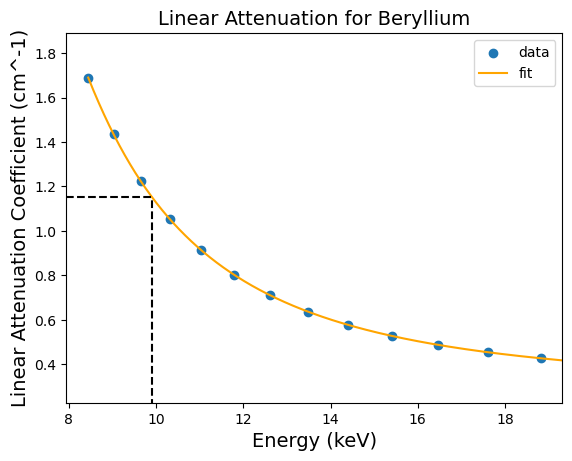

In [15]:
from scipy.interpolate import InterpolatedUnivariateSpline
E_values = np.array([8.447890, 9.030794, 9.653919, 10.32004, 11.03212, 11.79334, 12.60708, 13.47697, 14.40688, 15.40095, 16.46362, 17.59961, 18.81398]) #NIST
Mu_values = np.array([1.6899, 1.4343, 1.2233, 1.0526, 0.91442, 0.80237, 0.71141, 0.63743, 0.57712, 0.52787, 0.48754, 0.45444, 0.42714]) ##Nist
#Extrapolating to Experimental Photon Energy
low_bin = 0
high_bin = 12
Mu_Spline = InterpolatedUnivariateSpline(E_values, Mu_values)
Ref_Values = np.arange(np.float(E_values[low_bin]), np.float(E_values[high_bin]) + 0.5, .01, float)
fit_pattern = Mu_Spline(Ref_Values)

Energy_Bin = np.digitize(Average_Energy, Ref_Values)
linear_attenuation_coefficient_Be = fit_pattern[Energy_Bin]
print('Be cross section is %.3f cm^2/g' % linear_attenuation_coefficient_Be)

plt.figure()
plt.scatter(E_values, Mu_values, label = 'data')
plt.plot(Ref_Values, fit_pattern, color = 'orange', label = 'fit')
plt.vlines(Average_Energy, np.min(Mu_values) - 10, linear_attenuation_coefficient_Be, linestyle = 'dashed', color = 'black')
plt.hlines(linear_attenuation_coefficient_Be, np.min(E_values) - 0.5, Average_Energy, linestyle = 'dashed', color = 'black')
plt.xlabel('Energy (keV)', fontsize = 14)
plt.ylabel('Linear Attenuation Coefficient (cm^-1)', fontsize = 14)
plt.title('Linear Attenuation for Beryllium', fontsize = 14)
plt.legend()
plt.xlim(np.min(E_values) - 0.5, np.max(E_values) + 0.5)
plt.ylim(np.min(Mu_values) - 0.2, np.max(Mu_values) + 0.2)
plt.show()
#plt.savefig('Mass_Attenuation_15_155.png')

## Efficiency Calculation

0.007882779809690548
0.0070560223519039395
0.0001152460766340454
0.9022012425012116
68
[0.04138233 0.05414058 0.06690102 0.07966419 0.09243061 0.1052008
 0.11797528 0.13075458 0.14353924 0.15632976 0.1691267  0.18193059
 0.19474195 0.20756134 0.22038929 0.23322635 0.24607307 0.25893001
 0.27179771 0.28467674 0.29756767 0.31047107 0.32338751 0.33631757
 0.34926183 0.3622209  0.37519536 0.38818581 0.40119288 0.41421716
 0.4272593  0.44031991 0.45339963 0.46649912 0.47961902 0.49276
 0.50592273 0.5191079  0.53231618 0.54554829 0.55880494 0.57208685
 0.58539474 0.59872938 0.61209152 0.62548192 0.63890138 0.65235068
 0.66583065 0.67934211 0.6928859  0.70646289 0.72007394 0.73371995
 0.74740184 0.76112053 0.77487696 0.78867212 0.80250699 0.81638258
 0.83029994 0.84426011 0.85826418 0.87231327 0.88640851 0.90055106
 0.91474213 0.92898293]


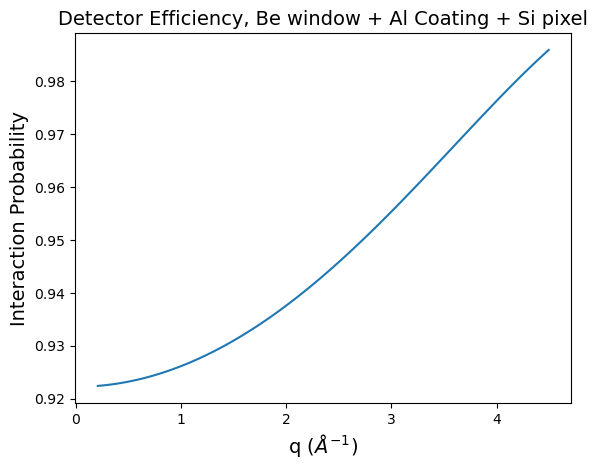

[0.92239555 0.92251646 0.9226696  0.92285494 0.92307241 0.92332197
 0.92360353 0.92391703 0.92426235 0.92463942 0.92504811 0.9254883
 0.92595985 0.92646261 0.92699643 0.92756113 0.92815651 0.92878238
 0.9294385  0.93012466 0.93084057 0.93158599 0.9323606  0.93316411
 0.93399616 0.9348564  0.93574446 0.93665991 0.93760233 0.93857125
 0.93956618 0.94058659 0.94163193 0.9427016  0.94379497 0.94491138
 0.94605011 0.94721042 0.9483915  0.94959252 0.95081258 0.95205074
 0.953306   0.95457731 0.95586355 0.95716356 0.95847609 0.95979984
 0.96113344 0.96247545 0.96382436 0.96517857 0.96653642 0.96789616
 0.96925596 0.97061393 0.97196807 0.97331631 0.97465651 0.97598643
 0.97730376 0.97860613 0.97989108 0.9811561  0.9823986  0.98361597
 0.98480555 0.98596465]


In [16]:
linear_attenuation_coefficient_Si = mass_attenuation_coefficient_Si*(2.3300)
linear_attenuation_coefficient_mu_Si = linear_attenuation_coefficient_Si/(1e4)
linear_attenuation_coefficient_mu_Al = linear_attenuation_coefficient_Al/(1e4)
linear_attenuation_coefficient_mu_Be = linear_attenuation_coefficient_Be/(1e4)

print(linear_attenuation_coefficient_mu_Si)
print(linear_attenuation_coefficient_mu_Al)
print(linear_attenuation_coefficient_mu_Be)

thickness_1 = 4.5 #microns, aluminum
thickness_2 = 100. #microns, Beryllium
thickness_3 = 318.5 #microns, Silicon

normal_incidence_detection = np.exp(-1*(linear_attenuation_coefficient_mu_Al*thickness_1) + (linear_attenuation_coefficient_mu_Be*thickness_2)) - np.exp(-1*((linear_attenuation_coefficient_mu_Al*thickness_1) + (linear_attenuation_coefficient_mu_Be*thickness_2) + (linear_attenuation_coefficient_mu_Si*thickness_3)))
print(normal_incidence_detection)

#def detection_ratio(angle):
#    return((np.exp((-1/np.cos(angle))*((linear_attenuation_coefficient_mu_Al*thickness_1)+(linear_attenuation_coefficient_mu_Be*thickness_2))) - np.exp((-1/np.cos(angle))*((linear_attenuation_coefficient_mu_Al*thickness_1) + (linear_attenuation_coefficient_mu_Be*thickness_2) + (linear_attenuation_coefficient_mu_Si*thickness_3)))))

def detection_ratio(angle):
    return(1 - np.exp((-1/np.cos(angle))*((linear_attenuation_coefficient_mu_Al*thickness_1) + (linear_attenuation_coefficient_mu_Be*thickness_2) + (linear_attenuation_coefficient_mu_Si*thickness_3))))

Energy_eV = Average_Energy*1000.
wavelength = 12400./Energy_eV

angles = 2*np.arcsin(qbins*wavelength/(4*np.pi))
print(angles.size)
print(angles)
detector_efficiency = detection_ratio(angles)


plt.figure()
plt.plot(qbins, detector_efficiency)
plt.xlabel('q ($\AA^{-1}$)', fontsize = 14)
plt.ylabel('Interaction Probability', fontsize = 14)
plt.title('Detector Efficiency, Be window + Al Coating + Si pixel', fontsize = 14)
plt.show()
#plt.savefig('Normal_Incidence_Updated.png')
print(detector_efficiency)
#np.save('detector_efficiency.npy', detector_efficiency)


## Cell to manually remove circles (Platinum scattering, etc.)

In [17]:
#Finding q_range to get rid of
kill_circle1 = np.where((matrix_q.flatten() > 2.75) & (matrix_q.flatten() < 2.82))[0]
kill_circle2 = np.where((matrix_q.flatten() > 3.16) & (matrix_q.flatten() < 3.23))[0]
#kill_circle3 = np.where((matrix_q.flatten() > 4.51) & (matrix_q.flatten() < 4.58))[0]
#kill_circle4 = np.where((matrix_q.flatten() > 5.31) & (matrix_q.flatten() < 5.38))[0]

cmask1_flat = cmask1.flatten()
cmask1_flat[kill_circle1] = 0
cmask1_flat[kill_circle2] = 0
#cmask1_flat[kill_circle3] = 0
#cmask1_flat[kill_circle4] = 0

cmask1_revised = np.reshape(cmask1_flat, (8,512,1024))
#np.save('Mask_Jungfrau_178_214_Platinum.npy', cmask1_revised)

print(np.sum(cmask2)/cmask2.size)


Plotting_Image_Flat = matrix_q.flatten()*jungfrau_sum.flatten()/azav[:,0].size
#Plotting_Image_Flat[kill_circle1] = 1
#Plotting_Image_Flat[kill_circle2] = 1
#Plotting_Image_Flat[kill_circle3] = 1
#Plotting_Image_Flat[kill_circle4] = 1
Plotting_Image = np.reshape(Plotting_Image_Flat, (8,512,1024))
Plotting_Image *= cmask2
Plotting_Image_1 = matrix_q*cmask*jungfrau_sum/azav[:,0].size
#Plotting_Image = cmask1
plt.figure(figsize=(9,6))
#pcm = plot_jungfrau(-y,x,Plotting_Image_1,vmin = np.min(Plotting_Image), vmax = 0.05, cmap = 'jet')
pcm = plot_jungfrau(-y,x,Plotting_Image, cmap = 'jet')
#pcm = plot_jungfrau(-y,x,cmask1,vmin = 0, vmax = 2, cmap = 'jet')
# pcm = plot_jungfrau(-y,x,jungfrau_sum,vmax=100) # For bkg, adjust the value at your own judgement
plt.colorbar(pcm)
neaten_plot(plt.gcf())
plt.show()
#plt.savefig('Without_Mask.png')

plt.figure(figsize=(9,6))
#pcm = plot_jungfrau(-y,x,Plotting_Image,vmin = np.min(Plotting_Image), vmax = 0.05, cmap = 'jet')# For SF6, higher scattering magnitude
pcm = plot_jungfrau(-y,x,cmask1,vmin = 0, vmax = 2, cmap = 'jet')
# pcm = plot_jungfrau(-y,x,jungfrau_sum,vmax=100) # For bkg, adjust the value at your own judgement
plt.colorbar(pcm)
neaten_plot(plt.gcf())
plt.show()
#plt.savefig('With_Mask.png')

print(jungfrau_sum.shape)

#plt.figure()
#hist,bins = np.histogram((jungfrau_sum).flatten(), bins=1000)
#loghist = np.log10(hist)
#plt.plot(bins[:-1],loghist)
#plt.savefig('run183_histogram.png')
#plt.show()

0.9333534240722656


NameError: name 'jungfrau_sum' is not defined

In [ ]:
#mask0 = cmask_tot
#mask0 = cmask2
mask0 = np.ones((8,512,1024))
#instrument_response = np.load('/reg/d/psdm/cxi/cxilx9320/results/Instrument_Response/IRF_Ne_run6.npy')
instrument_response = np.ones((8,512,1024))
jungfrau_sum = jungfrau_sum.astype('float64')
jungfrau_sum *= np.nan_to_num(mask0)
jungfrau_sum *= np.nan_to_num(instrument_response)

onshots = np.where(laserOn == True)[0]
offshots = np.where(laserOn == False)[0]
uvonshots = onshots.size
uvoffshots = offshots.size

jungfrau_sum /= (uvonshots + uvoffshots)

#pcm = plot_jungfrau(-y,x,jungfrau_sum,cmap = 'jet', vmin = 0)
pcm = plot_jungfrau(-y,x,on_sum,cmap='jet', vmin = 0, vmax = 50000)
#pcm = plot_jungfrau(-y,x,dropped_sum,cmap='jet')
# pcm = plot_jungfrau(-y,x,jungfrau_sum,vmax=1e-2)
plt.colorbar(pcm)
neaten_plot(plt.gcf())

print(uvonshots)
print(uvoffshots)

In [ ]:
print(np.unique(dropped_sum))
print(dropped_sum[4,10,10])

## Theory Curve Production

In [27]:
from radavg import RadialAverager
#x0, y0, z0, phi0 = -844.5140426812208, -227.0321805019465, 82468.90911901189, 0
#x0 = -817.2882941887514
#y0 = -254.8915187785341
#z0 = 85003.8628973143

x0 = -734.66
y0 = -213.26
z0 = 84160.04

phi0 = 0

wavelength = 0.77 #angstrom
X = x + x0
Y = y + y0
rr = np.sqrt((x)**2 + (y)**2) 
theta = np.arctan2(rr, z0) / 2.0
q = 4. * np.pi * np.sin(theta) / wavelength 
phi = np.arctan2((Y), (X)) + phi0 

nbins0 = 67 #103 # ~0.05 inverse angstrom per bin

ra = RadialAverager(q, mask=cmask, n_bins=nbins0)
q_bins = ra.bin_centers
cmap = 'jet'
print('done')
print(q_bins[1]-q_bins[0])

done
0.10129595700390015


In [28]:
theory_pattern = np.load('SF6_Debye_Total.npy') # change the path to your own theoretical patterns
q_theory = theory_pattern[:,0]
polarization = np.sin(phi)**2 + np.cos(phi)**2*np.cos(2*theta)**2 #shape Jungfrau
geometry = np.cos(2*theta)**3 #shape Jungfrau
pol_average = ra(polarization) #shape qbins
geo_average = ra(geometry) #shape qbins
pol_correction = np.interp(q_theory,q_bins,pol_average) #goes from shape qbins to shape theory
geo_correction = np.interp(q_theory, q_bins, geo_average) #goes from shape qbins to shape theory
print('done')

done


## Experiment Curve Production

## Uvons and Uvoffs from azav

In [29]:
run_value = 45.
from scipy.interpolate import InterpolatedUnivariateSpline
onshots = np.where((laserOn == True) & (dg2 > 2000))[0]
offshots = np.where((laserOn == False) & (dg2 > 2000))[0]
uvonshots = onshots.size
uvoffshots = offshots.size
print(uvonshots)
print(uvoffshots)
Intensity_Average = np.average(np.nan_to_num(dg2))
print(Intensity_Average)
dg2_on = np.reshape(np.repeat(dg2[onshots], azav[0,:].size), (onshots.size, azav[0,:].size))
dg2_off = np.reshape(np.repeat(dg2[offshots], azav[0,:].size), (offshots.size, azav[0,:].size))
uvoffs_radial = (azav[offshots,:]*Intensity_Average/dg2_off).sum(axis=0)
uvoffs_radial = np.nan_to_num(uvoffs_radial/uvoffshots) 
uvons_radial = (azav[onshots,:]*Intensity_Average/dg2_on).sum(axis=0)
uvons_radial = np.nan_to_num(uvons_radial/uvonshots)
uvoffs_spline = InterpolatedUnivariateSpline(qbins[0:qbins.size - 1],uvoffs_radial)
uvoffs1 = uvoffs_spline(matrix_q)
uvons_spline = InterpolatedUnivariateSpline(qbins[0:qbins.size - 1], uvons_radial)
uvons1 = uvons_spline(matrix_q)
mask0 = np.ones((8,512,1024))
instrument_response = np.ones((8,512,1024))
#mask0 = np.load('/cds/data/psdm/cxi/cxilw1118/results/masks/Mask_Jungfrau_8_7.npy') # path of mask to be applied
#instrument_response = np.load('/cds/data/psdm/cxi/cxilx6520/results/Instrument_Response/IRF_Ne_1runs_2022-06-11_run126_ExpFit_SGfilter_winSize11.npy') # path of IRF to be applied

# uvons1 is the laser on-shots total intensity    
#uvons1 *= np.nan_to_num(mask0)
#uvons1 *= np.nan_to_num(instrument_response)
IR_qbins = ra(instrument_response)
uvons_radial *= IR_qbins
uvoffs_radial *= IR_qbins
#uvons1 /= uvonshots1  #averaged by number of laser on shots
print('task complete') # prints "task complete" when this part/box of script gets completed

6136
4599
41136.449150004606
task complete


## Comparing to Cyclobutane

In [ ]:
Cyclobutane = np.load('IAM_refCBgeom-start.npy')

molecule = 'Cyclobutane'
scale = 0.0060
scale_JF = 110
theory = np.load('IAM_refCBgeom-start.npy') # change the path to your own theoretical patterns
q_theory = theory[0,:]
scattering_theory = theory[1,:]
#scattering_theory = scattering_theory*(geo_correction*pol_correction)

## This pattern to test the masks I made


plt.plot(q_theory[0:450], q_theory[0:450]*scattering_theory[0:450], color = 'green', label = '%s theory: IAM (total)' % molecule) # 
plt.plot(qbins[:-2], qbins[:-2]*uvoffs_radial[:-1]/scale, color = 'red', label = 'laser off')
plt.plot(qbins[:-2], qbins[:-2]*uvons_radial[:-1]/scale, color = 'blue', label = 'laser on')  
#plt.plot(qbins[:-1], qbins[:-1]*ra(jungfrau_sum)/scale_JF, color = 'orange', label = 'masked JF Sum')
plt.xlabel('q')
plt.ylabel('q*I(q)')
plt.xlim([0, 4.5])
plt.title('LX87 Run %d (%s): q*I(q) comparision with IRF' %(runNumbers[0], str(molecule)))
plt.legend()
plt.show()


## Comparing to Cyclopentanone

In [ ]:
molecule = 'CP'
scale = 0.0016
scale_JF = 110
theory = np.load('%s_Debye_Total.npy' % str(molecule)) # change the path to your own theoretical patterns
q_theory = theory[:, 0]
scattering_theory = theory[:, 1]
#scattering_theory = scattering_theory*(geo_correction*pol_correction)

## This pattern to test the masks I made


plt.plot(q_theory, q_theory**0*scattering_theory, color = 'green', label = '%s theory: IAM (total)' % molecule) # 
#plt.plot(qbins[:-1], qbins[:-1]*uvoffs_radial/scale, color = 'red', label = 'laser off')
#plt.plot(qbins[:-1], qbins[:-1]*uvons_radial/scale, color = 'blue', label = 'laser on')  
#plt.plot(qbins[:-1], qbins[:-1]*ra(jungfrau_sum)/scale_JF, color = 'orange', label = 'masked JF Sum')
plt.xlabel('q')
plt.ylabel('q*I(q)')
plt.xlim([0, 7])
plt.title('%s compared to run %d' % (str(molecule), runNumbers[0]))
plt.legend()
plt.show()

## For TMTAC

In [ ]:
from scipy.io import loadmat
import numpy as np
perdiff = loadmat('TMTAC_mono_dimer_IAM.mat')
scale = 4000

q_theory = np.array(perdiff['q'])
dimer = np.array(perdiff['TMTAC_dimer_total'])
mono = np.array(perdiff['TMTAC_mono_total'])

q_power = 1
mono_fraction = 0.6
dimer_fraction = 1.0 - mono_fraction

plt.figure()
plt.plot(q_theory[0,:], q_theory[0,:]**q_power*mono[0,:], color = 'green', label = 'monomer theory: IAM')  
#plt.plot(q_theory[0,:], q_theory[0,:]**q_power*dimer[0,:], color = 'red', label = 'dimer theory: IAM')
#plt.plot(q_theory[0,:], q_theory[0,:]**q_power*(mono_fraction*mono[0,:] + dimer_fraction*dimer[0,:]), label = 'mix, mono = %d percent' %(int(100*mono_fraction)))
plt.plot(qbins[:-1], scale*qbins[:-1]*uvons_radial/(detector_efficiency[:-1]), color = 'blue', label = 'laser on') 
plt.plot(qbins[:-1], scale*qbins[:-1]*uvoffs_radial/(detector_efficiency[:-1]), color = 'orange', label = 'laser off', linestyle = '--')
#plt.plot(qbins[:-1], qbins[:-1]*ra(jungfrau_sum)/scale_JF, color = 'orange', label = 'masked JF Sum')
plt.xlabel('q')
plt.ylabel('q*I(q)')
plt.xlim([0, 7.0])
plt.title('x10000 Run %d (TMTAC): q*I(q) comparision with IRF' % runNumbers[0])
plt.legend()
plt.show()

## Cyclobutanone

In [ ]:
molecule = 'C4H6O'
scale = 0.0016
scale_JF = 110
theory = np.load('%s_Debye_Total.npy' % str(molecule)) # change the path to your own theoretical patterns
q_theory = theory[:, 0]
scattering_theory = theory[:, 1]
#scattering_theory = scattering_theory*(geo_correction*pol_correction)

## This pattern to test the masks I made


plt.plot(q_theory, q_theory**0*scattering_theory, color = 'green', label = '%s theory: IAM (total)' % molecule) # 
#plt.plot(qbins[:-1], qbins[:-1]*uvoffs_radial/scale, color = 'red', label = 'laser off')
#plt.plot(qbins[:-1], qbins[:-1]*uvons_radial/scale, color = 'blue', label = 'laser on')  
#plt.plot(qbins[:-1], qbins[:-1]*ra(jungfrau_sum)/scale_JF, color = 'orange', label = 'masked JF Sum')
plt.xlabel('q')
plt.ylabel('q*I(q)')
plt.xlim([0, 7])
plt.title('LX87 Run 8 (SF6): q*I(q) comparision with IRF')
plt.legend()
plt.show()

# For SF6

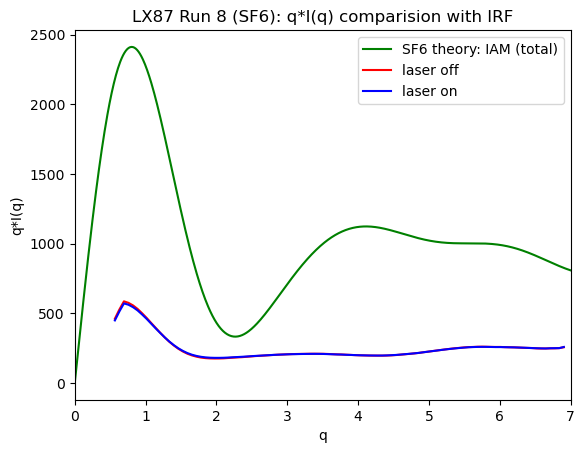

In [15]:
molecule = 'SF6'
scale = 185.
min_bin = 3
max_bin = 103
q_power = 1
scale_JF = .03
theory = np.load('SF6_Debye_Total.npy') # change the path to your own theoretical patterns
q_theory = theory[:, 0]
scattering_theory = theory[:, 1]
#scattering_theory = scattering_theory*(geo_correction*pol_correction)

## This pattern to test the masks I made


plt.plot(q_theory, q_theory**q_power*scattering_theory, color = 'green', label = '%s theory: IAM (total)' % molecule) # 
plt.plot(qbins[min_bin:max_bin], scale*qbins[min_bin:max_bin]**q_power*uvoffs_radial[min_bin:max_bin]/detector_efficiency[min_bin:max_bin], color = 'red', label = 'laser off')
plt.plot(qbins[min_bin:max_bin], scale*qbins[min_bin:max_bin]**q_power*uvons_radial[min_bin:max_bin]/detector_efficiency[min_bin:max_bin], color = 'blue', label = 'laser on')  
#plt.plot(qbins[:-1], scale_JF*qbins[:-1]*ra(jungfrau_sum), color = 'orange', label = 'masked JF Sum')
plt.xlabel('q')
plt.ylabel('q*I(q)')
plt.xlim([0, 7.0])
plt.title('LX87 Run 8 (SF6): q*I(q) comparision with IRF')
plt.legend()
plt.show()

# For Neon

In [ ]:
molecule = 'Neon'
scale = 144
q_power = 0
theory_pattern = np.transpose(np.loadtxt('Ne_total.txt')) # change the path to your own theoretical patterns
q_theory = theory_pattern[:,0]
scattering_theory = theory_pattern[:,1]



plt.figure()
plt.plot(q_theory, q_theory**q_power*scattering_theory, '-',color = 'green', label = '%s theory Ab initio' % molecule) # 
plt.plot(qbins[:-2], scale*qbins[:-2]**q_power*uvoffs_radial[:-1], color = 'red', label = 'laser off')
plt.plot(qbins[:-2], scale*qbins[:-2]**q_power*uvons_radial[:-1], color = 'blue', label = 'laser on') 
plt.xlabel('q')
plt.ylabel('q*I(q)')
plt.xlim([0 ,4.5])
plt.legend()
plt.title('LX87 Run 10 (Neon): q*I(q) comparision with IRF')
plt.show()

## For Xenon

In [ ]:
molecule = 'Xenon'
scale = 0.0002
theory_pattern = np.transpose(np.loadtxt('Xe_total.txt')) # change the path to your own theoretical patterns
q_theory = theory_pattern[:,0]
scattering_theory = theory_pattern[:,1]

plt.figure()
plt.plot(q_theory, q_theory*scattering_theory, '-',color = 'green', label = '%s theory Ab initio' % molecule) # 
plt.plot(qbins[:-1], qbins[:-1]*uvoffs_radial/scale, color = 'red', label = 'laser off')
plt.plot(qbins[:-1], qbins[:-1]*uvons_radial/scale, color = 'blue', label = 'laser on') 
plt.xlabel('q')
plt.ylabel('q*I(q)')
plt.xlim([0 ,7])
plt.legend()
plt.title('LV11 Run 145 (Xenon): q*I(q) comparision with IRF')
plt.show()

## Laser On vs Laser Off Plot

In [ ]:
nbins0 = 60
ra = RadialAverager(matrix_q, mask=mask0, n_bins=nbins0)
q_bins = ra.bin_centers[:-1]

plt.figure()
plt.plot(qbins[:-1], qbins[:-1]**0*uvoffs_radial, color = 'red', label = 'Laser Off')
plt.plot(qbins[:-1], qbins[:-1]**0*uvons_radial, color = 'blue', label = 'Laser On', linestyle = '--')
plt.xlabel('q')
plt.ylabel('I')
#plt.legend()
plt.title('Background run %d' % runNumbers[0])
#plt.title('I(q) run %d to %d' %(runs[0], runs[len(runs) - 1]))

print(uvoffs_radial)
plt.xlim([0,4.8])
plt.show()
#plt.savefig('Background.png')

#np.save('run20_background.npy', uvoffs_radial)

#plt.savefig('run%d_to_%d_radial_average.png' % (runs[0], runs[len(runs) - 1]))


## Background vs current I(q)

In [ ]:
background = np.load('run33_background.npy')
plt.figure()
plt.plot(qbins[:-1], qbins[:-1]**0*uvoffs_radial, color = 'red', label = 'Neon (Run 34)')
#plt.plot(qbins[:-1], qbins[:-1]**0*uvons_radial, color = 'blue', label = 'Laser On')
plt.plot(qbins[:-1], qbins[:-1]**0*background, label = 'background (run33)')
plt.xlabel('q', fontsize = 14)
plt.ylabel('I (keV/pixel)', fontsize = 14)
plt.legend()
plt.show()

# Comparing cyclobutanone percent difference to possible photoproducts

In [ ]:
CO = np.load('IAM_CO_b3lyp6-31Gstar.npy')
Cyclopropane = np.load('IAM_CP_b3lyp6-31Gstar1013.npy')
Ethene = np.load('IAM_E_b3lyp6-31Gstar1008.npy')
Ketene = np.load('IAM_K_b3lyp6-31Gstar1117.npy')
Propene = np.load('IAM_P_b3lyp6-31Gstar1039.npy')
Cyclobutane = np.load('IAM_refCBgeom-start.npy')

q_theory = CO[0,:]
CO_I = CO[1,:]
Cyclopropane_I = Cyclopropane[1,:]
Ethene_I = Ethene[1,:]
Ketene_I = Ketene[1,:]
Propene_I = Propene[1,:]
Cyclobutane_I = Cyclobutane[1,:]

K_plus_E_perdiff = ((Ketene_I + Ethene_I) - Cyclobutane_I)/Cyclobutane_I
CP_plus_CO_perdiff = ((Cyclopropane_I + CO_I) - Cyclobutane_I)/Cyclobutane_I
P_plus_CO_perdiff = ((Propene_I + CO_I) - Cyclobutane_I)/Cyclobutane_I

In [ ]:
scale_theory = 100*(0.06)

plt.figure()
#for i in range(0, len(delay_stage_positions)):
#    plt.plot(qbins[:-3], 100*(scales[i]*time_separated_signal_on[:-2,i] - time_separated_signal_off[:-2,i])/time_separated_signal_off[:-2,i], label = '%03f ps' % delay_stage_positions_ps[i])
plt.plot(qbins[:-3], 100*(uvons_radial[:-2] - uvoffs_radial[:-2])/uvoffs_radial[:-2], label = 'Experiment, all bins')
plt.plot(q_theory[0:450], scale_theory*K_plus_E_perdiff[0:450], label = 'Ketene + Ethene', linestyle = '--')
plt.plot(q_theory[0:450], scale_theory*CP_plus_CO_perdiff[0:450], label = 'Cyclopropane + CO', linestyle = '--')
plt.plot(q_theory[0:450], scale_theory*P_plus_CO_perdiff[0:450], label = 'Propene + CO', linestyle = '--')
plt.xlabel('q')
plt.ylabel('% Difference')
plt.legend()
#plt.xlim(0,16)
#plt.ylim(-0.4,0.8)
plt.title('Difference signal Run %d to %d' % (runNumbers[0], runNumbers[len(runNumbers) - 1]))
plt.show()
#plt.savefig('Difference_Signal_%d_%d.png' % (runNumbers[0], runNumbers[len(runNumbers) - 1]))

## Finding optimal product mix for the data

In [ ]:
from scipy.interpolate import InterpolatedUnivariateSpline

KE_Spline = InterpolatedUnivariateSpline(q_theory, K_plus_E_perdiff)
CPCO_Spline = InterpolatedUnivariateSpline(q_theory, CP_plus_CO_perdiff)
PCO_Spline = InterpolatedUnivariateSpline(q_theory, P_plus_CO_perdiff)

Splined_KE = 100*KE_Spline(qbins[:-1])
Splined_CPCO = 100*CPCO_Spline(qbins[:-1])
Splined_PCO = 100*PCO_Spline(qbins[:-1])


In [ ]:
from scipy.optimize import minimize
Product_Fractions = np.zeros(3)
Scales_Theory = np.zeros(1)
x0 = np.array([0.333,0.333,0.334, 1])
method = 'SLSQP'
#method = 'Nelder-Mead'
bounds = np.array([(0,1), (0,1), (0,1), (0.01, 100)])


def product_mix(coef_KE, coef_CPCO, coef_PCO, scale):
    return (scale)*(coef_KE*Splined_KE + coef_CPCO*Splined_CPCO + coef_PCO*Splined_PCO)
def error(x):
    return np.sum(np.abs(np.nan_to_num((product_mix(x[0], x[1], x[2], x[3]) - (uvons_radial - uvoffs_radial)/uvoffs_radial))))          
best_values = minimize(error, x0 = x0, method = method, bounds = bounds)
Product_Fractions[:] = best_values.x[0:3]
Scales_Theory[0] = best_values.x[3]

In [ ]:

plt.figure()
plt.plot(qbins[:-3], 100*(uvons_radial[:-2] - uvoffs_radial[:-2])/uvoffs_radial[:-2], label = 'Experiment, all bins')
plt.plot(qbins[:-3], 100*Scales_Theory[0]*(Product_Fractions[0]*Splined_KE[:-2] + Product_Fractions[1]*Splined_CPCO[:-2] + Product_Fractions[2]*Splined_PCO[:-2]), label = 'Mixed Product', linestyle = '--')
plt.xlabel('q')
plt.ylabel('% Difference')
plt.legend()
#plt.xlim(0,16)
#plt.ylim(-0.4,0.8)
Coefficients_Final = (1/np.sum(Product_Fractions[:]))*Product_Fractions[:]
plt.title('KE %.3f, CPCO %.3f, PCO %.3f' % (Coefficients_Final[0], Coefficients_Final[1], Coefficients_Final[2]))
plt.show()
#plt.savefig('Difference_Signal_%d_%d.png' % (runNumbers[0], runNumbers[len(runNumbers) - 1]))

## Mask Test

In [ ]:
unmasked = jungfrau_sum
masked = jungfrau_sum*cmask2
power = 2

unmasked_ra = ra(unmasked)
masked_ra = ra(masked)
cmask2_ra = ra(cmask2)

plt.figure()
plt.plot(q_bins**power*unmasked_ra[0:59], label = 'unmasked Pt')
plt.plot(q_bins**power*masked_ra[0:59]/cmask2_ra[0:59], '--', label = 'masked Pt')
#plt.plot(100*(masked_ra-unmasked_ra)/unmasked_ra, label = 'percent difference')
plt.legend()
plt.xlabel('q')
plt.ylabel('I')
plt.title('Run %d Mask Testing' % runNumbers[0])
plt.show()
#plt.savefig('Mask_Testing.png')

## Background vs Sample Plot

In [ ]:
nbins0 = 69
ra = RadialAverager(matrix_q, mask=mask0, n_bins=nbins0)
q_bins = ra.bin_centers[:-1]

#np.save('background_%d.npy' % runNumbers[0],uvons_radial)

back = np.load('run20_background.npy')
back1 = np.load('run21_background.npy')
back2 = np.load('run22_background.npy')
back3 = np.load('run23_background.npy')
#back4 = np.load('background_125.npy')
#back5 = np.load('background_183.npy')

plt.figure()
#plt.plot(qbins[:-1], qbins[:-1]**0*np.log10(uvons_radial), color = 'red', label = 'background run %d' % runNumbers[0])
plt.plot(qbins[:-1], qbins[:-1]**0*np.log10(back), color = 'blue', label = 'Background run20')
plt.plot(qbins[:-1], qbins[:-1]**0*np.log10(back1), color = 'green', label = 'Background run21')
plt.plot(qbins[:-1], qbins[:-1]**0*np.log10(back2), color = 'violet', label = 'Background run22')
plt.plot(qbins[:-1], qbins[:-1]**0*np.log10(back3), color = 'orange', label = 'Background run23')
#plt.plot(qbins[:-2], qbins[:-2]**0*np.log10(back4), color = 'orange', label = 'Background run125')
#plt.plot(qbins[:-1], qbins[:-1]**0*np.log10(back5), color = 'yellow', label = 'Background run183')
plt.xlabel('q')
plt.ylabel('log10(I)')
plt.legend()
plt.title('Background over time')
#plt.title('I(q) run %d to %d' %(runs[0], runs[len(runs) - 1]))

plt.xlim([0,4.8])
plt.show()
#plt.savefig('Both_Log10.png')

#plt.savefig('run%d_to_%d_radial_average.png' % (runs[0], runs[len(runs) - 1]))


## Percent Difference Pattern (Need Percent Difference Pattern)

/tmp/ipykernel_2431093/1841927685.py:1: RuntimeWarning: invalid value encountered in divide
  percent_difference = 100*(uvons_radial - uvoffs_radial)/uvoffs_radial


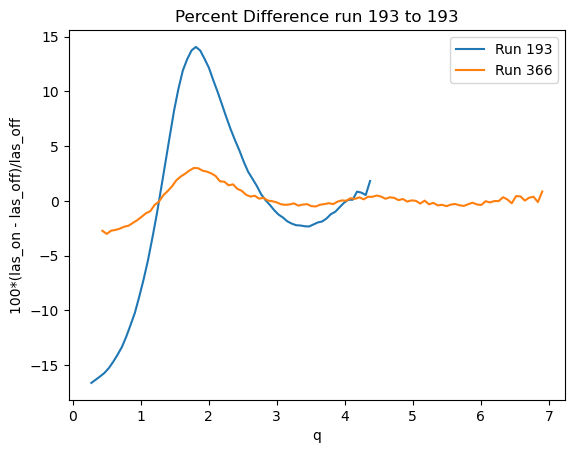

In [30]:
percent_difference = 100*(uvons_radial - uvoffs_radial)/uvoffs_radial
pd_old = np.load('run366_perdiff.npy')
pd_x = pd_old[:,0]
pd_y = pd_old[:,1]
#theory_perdiff = np.load('CHD_HT_Percent_Difference.npy')
#print(theory_perdiff.shape)
plt.figure()
plt.plot(qbins[:-2], percent_difference[:-1], label = 'Run %d' % runNumbers[0])
plt.plot(pd_x, pd_y, label = 'Run 366')
#plt.plot(theory_perdiff[0:400,0], 0.53*theory_perdiff[0:400,1], label = 'theory CHD -> HT')
plt.legend()
plt.title('Percent Difference run %d to %d' % (runNumbers[0], runNumbers[len(runNumbers) -1]))
plt.ylabel('100*(las_on - las_off)/las_off')
plt.xlabel('q')
plt.show()
#plt.savefig('run%d.png' % runNumbers[0])

save_array = np.zeros((percent_difference.size,2))
save_array[:,0] = qbins[:-1]
save_array[:,1] = percent_difference
#np.save('run%d_perdiff.npy' % runNumbers[0], save_array)

## Setting up the theory percent difference patterns

In [ ]:
# path 1 = 

In [ ]:
print(run_indicator.shape)
print(np.unique(scan)[20])
print(scan.shape)

5
0
1
2
3
4


/tmp/ipykernel_297907/1344484987.py:34: RuntimeWarning: invalid value encountered in divide
  dI_I = (uvons_radial-uvoffs_radial)/uvoffs_radial


(67, 5)


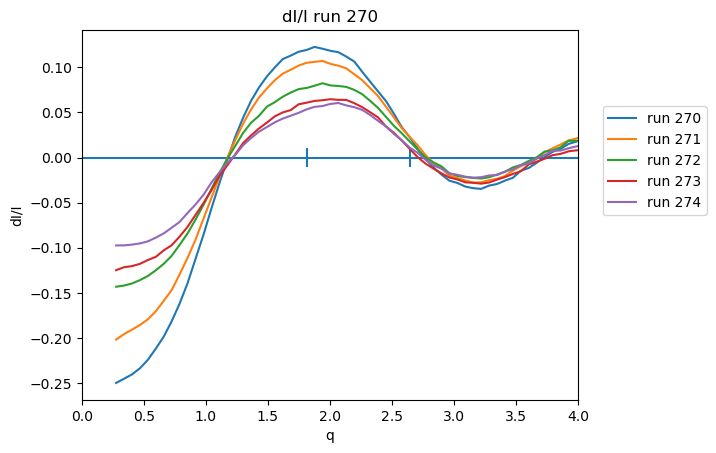

In [15]:
from scipy.interpolate import InterpolatedUnivariateSpline
print(len(runNumbers))
i = 0
uvoffs_radial = np.zeros((azav[0,:].size,len(runNumbers)))
uvons_radial = np.zeros((azav[0,:].size,len(runNumbers)))
xrayoff_radial = np.zeros((azav[0,:].size,len(runNumbers)))
xrayon_radial = np.zeros((azav[0,:].size,len(runNumbers)))

def normalization(x):
    return x/np.max(x)


for runNumber in runNumbers:
#    if i > 0: continue
    print(i)
    onshots = np.where((laserOn == True) & (dg2 > 200) &(run_indicator==runNumber))[0]
    #onshots = np.where((laserOn == True) & (dg2 > 200) &(run_indicator==runNumber) & (scan >= np.unique(scan)[20]))[0]
    offshots = np.where((laserOn == False) & (dg2 > 200)&(run_indicator==runNumber))[0]
    noxrays = np.where((xrayOn2 == False))
    withxrays = np.where((xrayOn2 == True))
    uvonshots = onshots.size
    uvoffshots = offshots.size
    Intensity_Average = np.average(np.nan_to_num(dg2[(dg2 > 200)&(run_indicator==runNumber)]))
    dg2_on = np.reshape(np.repeat(dg2[onshots], azav[0,:].size), (onshots.size, azav[0,:].size))
    dg2_off = np.reshape(np.repeat(dg2[offshots], azav[0,:].size), (offshots.size, azav[0,:].size))
    xrayoff_radial[:,i] = (azav[noxrays,:]).sum(axis=1)
    xrayon_radial[:,i] = (azav[withxrays,:]).sum(axis=1)
    uvoffs_radial[:,i] = (azav[offshots,:]*Intensity_Average/dg2_off).sum(axis=0)
    uvoffs_radial[:,i]  = np.nan_to_num(uvoffs_radial[:,i]/uvoffshots)
    uvons_radial[:,i]  = (azav[onshots,:]*Intensity_Average/dg2_on).sum(axis=0)
    uvons_radial[:,i]  = np.nan_to_num( uvons_radial[:,i]/uvonshots)
    i +=1
import pandas as pd
dI_I = (uvons_radial-uvoffs_radial)/uvoffs_radial
sums = np.sum(uvons_radial[25:38,:] - uvoffs_radial[25:38,:]/uvoffs_radial[25:38,:], axis = 0)
print(dI_I.shape)
plt.figure()
plt.vlines(qbins[25], -0.01, 0.01)
plt.vlines(qbins[38], -0.01, 0.01)
plt.hlines(0, 0, 4)
for i in range (0,len(runNumbers)):
    y = dI_I[:,i]
    plt.plot(qbins[:-1], y,label=f"run {runNumbers[i]}")
    #plt.plot(qbins[:-1], normalization(pd.Series(y).rolling(window=3).mean()),label=f"run {runNumbers[i]}")
plt.xlabel('q')
plt.ylabel('dI/I')
plt.xlim([0,4])
plt.legend(loc=[1.05,0.5])
plt.title('dI/I run %d' % runNumbers[0])
#plt.title('Late timebin signal strength = (LaserOn - Laser off)/Laser off')
#plt.title('I(q) run %d to %d' %(runs[0], runs[len(runs) - 1]))
#plt.title('DI Vs q')
#plt.ylim(-0.013,0.01)
plt.show()

In [ ]:
plt.figure()
plt.scatter(runNumbers, sums)
plt.xlabel('run number')
plt.ylabel('integrated sum')
plt.show()

In [ ]:
run38 = np.load('run38_perdiff.npy')
run39 = np.load('run39_perdiff.npy')
run40 = np.load('run40_perdiff.npy')
run41 = np.load('run41_perdiff.npy')
run42 = np.load('run42_perdiff.npy')

plt.figure()
plt.plot(theory_perdiff[0,:], theory_perdiff[1,:], label = 'theory')
plt.plot(qbins[:-1], run38, label = 'run 38')
plt.plot(qbins[:-1], run39, label = 'run 39, 2.4 uJ')
plt.plot(qbins[:-1], run40, label = 'run 40, 9.22 uJ')
plt.plot(qbins[:-1], run41, label = 'run 41, 11.59 uJ')
plt.plot(qbins[:-1], run42, label = 'run 42, 14.26 uJ')
plt.legend()
plt.title('Percent Difference Power Scan')
plt.xlabel('q')
plt.ylabel('% difference')
#plt.show()
plt.savefig('run%d.png' % runNumbers[0])
np.save('run%d_perdiff.npy' % runNumbers[0], percent_difference)